In [ ]:
import pandas as pd
import numpy as np
import glob, os, shutil, cv2, json, sys
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import scipy.ndimage as ndimage
from tqdm import tqdm


def getFiles(path, limit=None, shuffle=False):
    target = sorted(glob.glob(os.path.join(path, '*')))
    if shuffle:
        np.random.shuffle(target) 
    return target[:limit]

def formatAxis(img):
    return np.transpose(img, (0, 2, 1))

def setFolder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)

def showTile(img, mask=False):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    mid_x = img.shape[0] // 2
    mid_y = img.shape[1] // 2
    mid_z = img.shape[2] // 2

    slices = [
        img[mid_x, :, :],  # Plano YZ (Corte ao longo do eixo X)
        img[:, mid_y, :],  # Plano XZ (Corte ao longo do eixo Y)
        img[:, :, mid_z]   # Plano XY (Corte ao longo do eixo Z)
    ]

    slices[0] = np.array(slices[0])
    arr_y = np.array(slices[1])
    arr_z = np.array(slices[2])
    slices[1] = np.rot90(arr_z, -1)
    slices[2] = arr_y

    cmap_config = ListedColormap(['black', 'red', 'green', 'blue']) if mask else 'gray'
    vmin, vmax  = (0, 3) if mask else (None, None)
    titles = [f'Slice X={mid_x}', f'Slice Y={mid_y}', f'Slice Z={mid_z}']
    
    for i, ax in enumerate(axes):
        ax.imshow(slices[i], cmap=cmap_config, vmin=vmin, vmax=vmax)
        ax.set_title(titles[i])
    
    plt.tight_layout()
    plt.show()

### Variáveis que melhoram a qualidade/nitidez
- self.waveletFreq = (45, 65)    # Frequência alta = nitidez
- self.noiseLevel = (0.0, 0.01)  # Quase zero ruído
- self.layerThickness = (1, 3)   # Camadas finas
- self.faultRoughness = 1.0      # Falhas mais limpas e retas

In [2]:
class SyntheticGenerator:
    def __init__(self, shape=(128, 128, 128)):
        # ── Image Format ─────────────────────────────────────────────
        self.margin = 64                  # Buffer aumentado para absorver dobras extremas com segurança
        self.zoom   = 1.8                 # >1.0 zoom out (more structures), <1.0 zoom in (finer detail)
        
        # ── Output geometry ──────────────────────────────────────────
        self.finalShape = shape           # (nx, ny, nz) final output volume size
        self.zoom = max(self.zoom, 0.1)  

        # ── Refletividade (Estratigrafia) ────────────────────────────
        self.layerRange = (80, 160)       
        self.layerThickness = (1, 4)      # Espessura base de cada camada em voxels (será multiplicada pela escala/zoomRange).
        self.layerNoise = 0.01            # Heterogeneidade interna da camada (rugosidade da rocha). Valores altos = textura mais "suja".

        # ── Dobramentos (Folding) ────────────────────────────────────
        self.foldCount = (15, 30)         # Quantidade mínima e máxima de dobras (Gaussianas). Mais dobras = geologia mais caótica.
        self.foldSigma = (15, 80)         # Largura base de cada dobra (será multiplicada pela escala).
        self.foldAmplitude = (-30, 30)    # Amplitude base do deslocamento vertical da dobra (será multiplicada pela escala).
        self.foldDamping = 1.5            # Fator de amortecimento. Valores altos fazem com que as camadas mais profundas dobrem menos.
        self.foldBaseShift = (-3, 3)      # Deslocamento vertical global. Move o bloco de rocha inteiro para cima ou para baixo.

        # ── Cisalhamento / Inclinação (Shearing) ─────────────────────
        self.shearOffset   = (-5, 5)      # Intervalo de deslocamento da inclinação (tilt) global.
        self.shearGradient = (-0.1, 0.1)  # Gradiente de mergulho (dip) por eixo. Define o quão "íngreme" fica a inclinação geral.

        # ── Falhas (Faulting) ────────────────────────────────────────
        self.faultCount = (4, 7)          # Número mínimo e máximo de falhas por cubo.
        self.faultThrow = (0, 40)         # Rejeito (deslocamento vertical) da falha em voxels (será multiplicado pela escala).
        self.faultDipAngle = (20, 75)     # Ângulo de mergulho em Graus. (0 = horizontal, 90 = vertical)
        
        self.faultRoughness  = 6.0        # Rugosidade do plano de falha. Valores altos = falhas irregulares/onduladas. 0 = corte de faca.
        self.faultRoughSigma = 8          # Nível de suavização dessa rugosidade da falha. Valores altos deixam a ondulação mais suave.
        self.faultDecaySigma = (60, 150)  # O quão longe o deslocamento (rejeito) da falha afeta as rochas vizinhas (decaimento).
        self.faultZoneWidth  = 2.5        # Espessura da "zona" de falha na hora de gerar a máscara binária (labels para a CNN).
        self.faultThreshold  = 1.5        # Rejeito mínimo exigido para o código classificar aquele pixel como "falha" na máscara.
        self.faultCurveProb  = 0.35       # Probabilidade (0 a 1) de uma falha nascer curvada (ex: 0.30 = 30% de chance).
        self.faultCurveMax   = 20.0       # O quão "torta" (desvio máximo em voxels) a falha curvada pode ficar.

        # ── Assinatura Sísmica (Wavelet) ─────────────────────────────
        self.waveletFreq = (45, 65)       # Frequência da Wavelet de Ricker em Hz. Mais alta = pulso mais fino e resolução sísmica maior.
        self.waveletDuration = 0.08       # Meia-duração do pulso da wavelet (em segundos). Valores maiores = pulso mais largo.
        self.waveletDt = 0.002            # Intervalo de amostragem no tempo (taxa digital). 0.002 é o padrão (2ms).

        # ── Ruído Final (Noise) ──────────────────────────────────────
        self.noiseLevel = (0.00, 0.05)    # Quantidade de ruído gaussiano (chuvisco) misturado à imagem sísmica final.

        # ── Internal working volume ──────────────────────────────────
        extraMargin = int(np.ceil(max(shape) * (self.zoom - 1.0) / 2.0)) if self.zoom > 1.0 else 0
        self.nx = shape[0] + 2 * (self.margin + extraMargin)
        self.ny = shape[1] + 2 * (self.margin + extraMargin)
        self.nz = shape[2] + 2 * (self.margin + extraMargin)
        self.shape = (self.nx, self.ny, self.nz)

    def get(self):
        data = self.genReflectivity()
        data = self.applyFolding(data)
        data = self.applyShearing(data)
        data, mask = self.applyFaulting(data)
        image = self.applyWavelet(data)
        image = self.applyNoise(image)

        image = self.crop(image)
        mask  = self.crop(mask)
        image = (image - np.mean(image)) / (np.std(image) + 1e-8)
        return image.astype(np.float32), mask.astype(np.uint8)

    def dataset(self, n=200, outputDir="output"):
        imgDir = os.path.join(outputDir, "images")
        mskDir = os.path.join(outputDir, "masks")
        setFolder(imgDir)
        setFolder(mskDir)

        for i in tqdm(range(n), desc="Generating dataset"):
            image, mask = self.get()
            image, mask = formatAxis(image), formatAxis(mask)
            
            np.save(os.path.join(imgDir, f"img_{i:04d}.npy"), image)
            np.save(os.path.join(mskDir, f"img_{i:04d}.npy"), mask)

    def genReflectivity(self):
        """Create 1D layered reflectivity tiled across the volume."""
        r1d = np.zeros(self.nz)
        nLayers = np.random.randint(*self.layerRange)

        for _ in range(nLayers):
            pos = np.random.randint(0, self.nz)
            thickness = np.random.randint(*self.layerThickness)
            r1d[pos : pos + thickness] = np.random.uniform(-1, 1)

        r1d += np.random.normal(0, self.layerNoise, self.nz)
        r3d = np.tile(r1d, (self.nx, self.ny, 1))
        
        noise3d = np.random.normal(0, 1, self.shape)
        smoothedNoise = ndimage.gaussian_filter(noise3d, sigma=(1.0, 1.0, 0.0))
        smoothedNoise *= (self.layerNoise * 10 / (np.std(smoothedNoise) + 1e-8))
        
        return r3d + smoothedNoise

    def applyFolding(self, reflectivity):
        """Deform layers with rotated anisotropic Gaussian folds."""
        x = np.arange(self.nx)
        y = np.arange(self.ny)
        xx, yy = np.meshgrid(x, y, indexing="ij")

        a0 = np.random.uniform(*self.foldBaseShift)
        nGaussians = np.random.randint(*self.foldCount)
        shift2d    = np.zeros((self.nx, self.ny))

        for _ in range(nGaussians):
            x0 = np.random.uniform(-self.nx * 0.3, self.nx * 1.3)
            y0 = np.random.uniform(-self.ny * 0.3, self.ny * 1.3)
            sigmaX = np.random.uniform(*self.foldSigma)
            sigmaY = np.random.uniform(*self.foldSigma)
            theta  = np.random.uniform(0, np.pi)
            amp = np.random.uniform(*self.foldAmplitude)

            dx = xx - x0
            dy = yy - y0
            cosT, sinT = np.cos(theta), np.sin(theta)
            u = cosT * dx + sinT * dy
            v = -sinT * dx + cosT * dy
            shift2d += amp * np.exp(-(u**2 / (2 * sigmaX**2) + v**2 / (2 * sigmaY**2)))

        zGrid = np.arange(self.nz)
        damping = self.foldDamping * zGrid / (self.nz - 1)
        s1 = a0 + shift2d[:, :, np.newaxis] * damping

        ix, iy, iz = np.indices(self.shape)
        return ndimage.map_coordinates(reflectivity, [ix, iy, iz + s1], order=3, mode="nearest")

    def applyShearing(self, reflectivity):
        """Apply linear shear (dip/tilt) along X and Y axes."""
        e0 = np.random.uniform(*self.shearOffset)
        f  = np.random.uniform(*self.shearGradient)
        g  = np.random.uniform(*self.shearGradient)

        ix, iy, iz = np.indices(self.shape)
        s2 = e0 + f * ix + g * iy
        return ndimage.map_coordinates(reflectivity, [ix, iy, iz + s2], order=3, mode="nearest")

    def applyFaulting(self, reflectivity):
        """Inject faults with displacement and produce binary mask."""
        masks = np.zeros(self.shape, dtype=np.uint8)
        model = np.copy(reflectivity)

        numFaults  = np.random.randint(*self.faultCount)
        ix, iy, iz = np.indices(self.shape)

        for i in range(numFaults):
            p0 = np.random.uniform(0.15, 0.85, 3) * np.array(self.shape)

            dip_angle  = np.random.uniform(*self.faultDipAngle)
            dip_rad    = np.deg2rad(dip_angle)
            strike_rad = np.random.uniform(0, 2 * np.pi)
            nx = np.sin(dip_rad) * np.cos(strike_rad)
            ny = np.sin(dip_rad) * np.sin(strike_rad)
            nz = np.cos(dip_rad) * np.random.choice([-1.0, 1.0])
            normal = np.array([nx, ny, nz])

            strike = np.array([-normal[1], normal[0], 0.0])
            strikeNorm = np.linalg.norm(strike)
            strike = np.array([1.0, 0.0, 0.0]) if strikeNorm < 1e-6 else strike / strikeNorm
            dip = np.cross(normal, strike)
            dip /= np.linalg.norm(dip)

            dx = ix - p0[0]
            dy = iy - p0[1]
            dz = iz - p0[2]

            distStrike = strike[0] * dx + strike[1] * dy + strike[2] * dz
            distDip = dip[0] * dx + dip[1] * dy + dip[2] * dz
            bend    = 0.0
            
            if np.random.random() < self.faultCurveProb:
                max_dist = max(self.shape) / 1.5 
                intensidade_base = np.random.uniform(self.faultCurveMax * 0.5, self.faultCurveMax)
                direcao = np.random.choice([-1.0, 1.0])
                curve_intensity = intensidade_base * direcao
                bend = curve_intensity * ((distDip / max_dist) ** 2)

            noisePlane = ndimage.gaussian_filter(np.random.normal(0, 1, self.shape), sigma=self.faultRoughSigma) * self.faultRoughness
            distPlane  = normal[0] * dx + normal[1] * dy + normal[2] * dz + noisePlane - bend
            maxDisp  = np.random.uniform(*self.faultThrow)
            throwMap = self.computeThrowMap(distStrike, distDip, maxDisp)

            izShifted = iz.astype(float)
            izShifted[distPlane > 0] += throwMap[distPlane > 0]

            model     = ndimage.map_coordinates(model, [ix, iy, izShifted], order=1, mode="nearest")
            faultZone = (np.abs(distPlane) < self.faultZoneWidth) & (np.abs(throwMap) > self.faultThreshold)
            masks[faultZone] = 1

        return model, masks

    def computeThrowMap(self, distStrike, distDip, maxDisp):
        """Compute displacement map for a single fault (gaussian or linear decay)."""
        if np.random.random() < 0.5:
            sigmaPlane = np.random.uniform(*self.faultDecaySigma)
            return maxDisp * np.exp(-(distStrike**2 + distDip**2) / (2 * sigmaPlane**2))

        planeExtent = np.sqrt(self.nx**2 + self.ny**2 + self.nz**2)
        direction   = np.random.choice([-1, 1])
        return maxDisp * np.clip(0.5 + direction * distDip / planeExtent, 0, 1)

    def applyWavelet(self, model):
        """Convolve with a Ricker wavelet along the Z axis."""
        f = np.random.uniform(*self.waveletFreq)
        t = np.arange(-self.waveletDuration, self.waveletDuration, self.waveletDt)
        wavelet = (1 - 2 * (np.pi * f * t) ** 2) * np.exp(-((np.pi * f * t) ** 2))
        return ndimage.convolve1d(model, wavelet, axis=2)

    def applyNoise(self, image):
        """Add band-limited Gaussian noise scaled to signal amplitude."""
        scale = np.random.uniform(*self.noiseLevel) * np.std(image)
        noise = np.random.normal(0.0, 1.0, image.shape)
        noise = ndimage.gaussian_filter(noise, sigma=(1.0, 1.0, 0.5))
        noise *= (scale / (np.std(noise) + 1e-8))
        
        image = image + noise
        image = ndimage.gaussian_filter(image, sigma=(0.5, 0.5, 0))
        return image

    def crop(self, volume):
        """Extract a zoomed region from the center and resize to finalShape."""
        fx, fy, fz = self.finalShape
        cx, cy, cz = volume.shape[0] // 2, volume.shape[1] // 2, volume.shape[2] // 2

        ex = int(round(fx * self.zoom / 2.0))
        ey = int(round(fy * self.zoom / 2.0))
        ez = int(round(fz * self.zoom / 2.0))

        x0, x1  = max(cx - ex, 0), min(cx + ex, volume.shape[0])
        y0, y1  = max(cy - ey, 0), min(cy + ey, volume.shape[1])
        z0, z1  = max(cz - ez, 0), min(cz + ez, volume.shape[2])
        cropped = volume[x0:x1, y0:y1, z0:z1]

        if cropped.shape == (fx, fy, fz):
            return cropped

        zoomFactors = (fx / cropped.shape[0], fy / cropped.shape[1], fz / cropped.shape[2])
        order = 0 if volume.dtype == np.uint8 else 3
        return ndimage.zoom(cropped, zoomFactors, order=order)

showing img 0


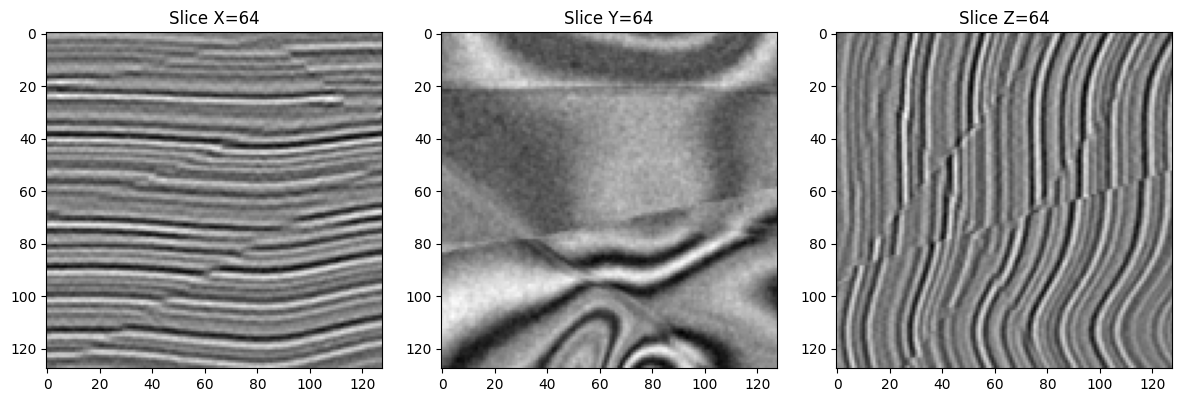

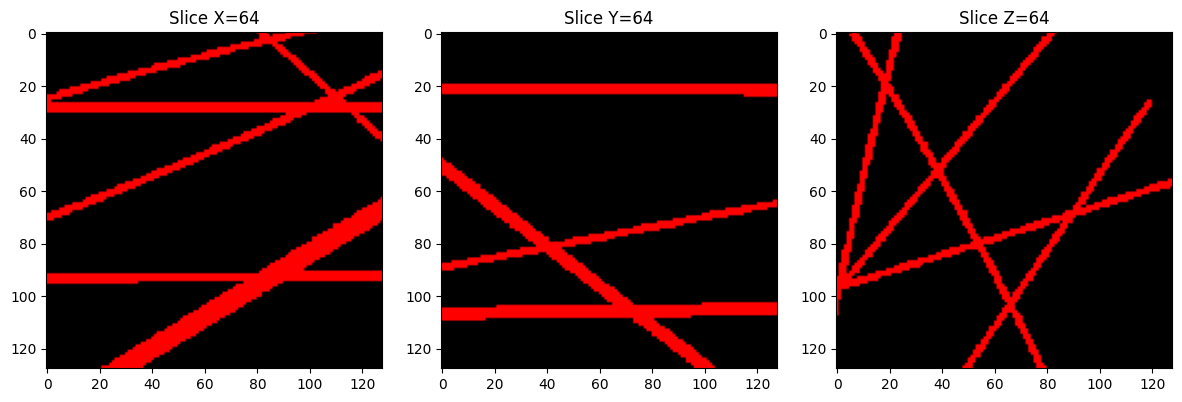




showing img 1


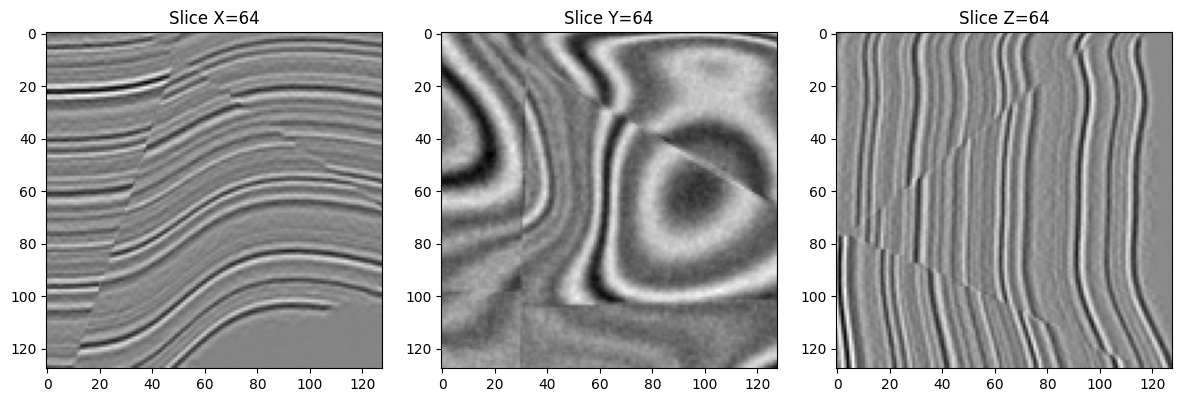

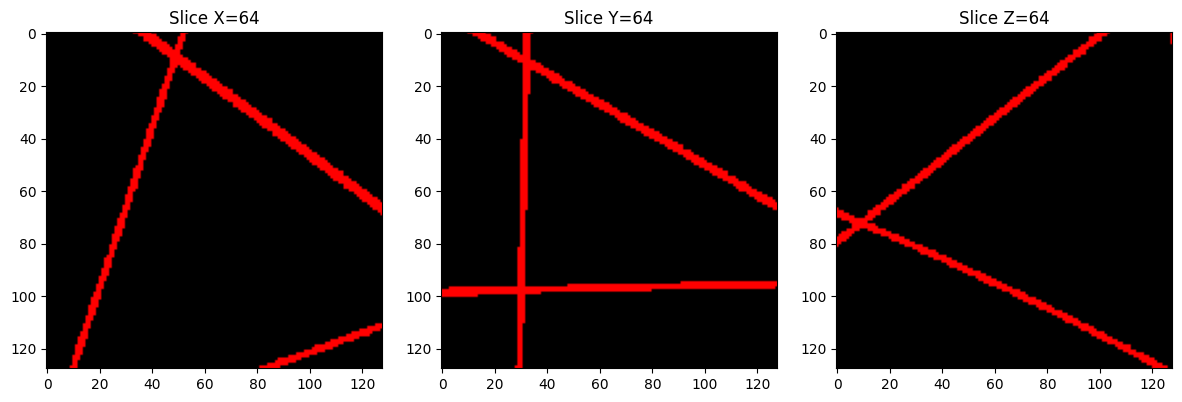




showing img 2


In [ ]:
gen = SyntheticGenerator()

for i in range(5):
    print('showing img', i)
    image, mask = gen.get()    
    image, mask = formatAxis(image), formatAxis(mask)

    showTile(image)
    showTile(mask, mask=True)
    print('\n\n')

# APLICANDO DATASET

In [ ]:
SAVE_DATA = True

In [ ]:
if SAVE_DATA:
    gen = SyntheticGenerator()
    gen.dataset(n=200, outputDir='../Dataset/dataset1/original')

Generating dataset: 100%|██████████| 200/200 [3:46:46<00:00, 68.03s/it]  
